# EDA - Traffic Crash Severity

Quick exploratory analysis to understand patterns in crash severity.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [34]:
PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data: {DATA_PROCESSED}")
print(f"Figures directory: {FIGURES_DIR}")

Project root: /Users/eugene/Documents/SJSU MSSE/Spring26/CMPE-255_Data-Mining/GroupProject/CMPE255_TrafficCrashSeverityIndicator
Processed data: /Users/eugene/Documents/SJSU MSSE/Spring26/CMPE-255_Data-Mining/GroupProject/CMPE255_TrafficCrashSeverityIndicator/data/processed
Figures directory: /Users/eugene/Documents/SJSU MSSE/Spring26/CMPE-255_Data-Mining/GroupProject/CMPE255_TrafficCrashSeverityIndicator/reports/figures


## 1. Load Data

In [35]:
df = pd.read_csv(DATA_PROCESSED / 'merged_crash_vehicle_data.csv', low_memory=False)

if 'CrashDateTime' in df.columns:
    df['CrashDateTime'] = pd.to_datetime(df['CrashDateTime'])
if 'crash_date' in df.columns:
    df['crash_date'] = pd.to_datetime(df['crash_date'])

print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Date range: {df['crash_year'].min()} - {df['crash_year'].max()}")

# Note: SpeedingFlag and HitAndRunFlag only exist in 2022+ data (82% missing)
# These can be dropped for modeling if needed
print(f"\nColumns with 2022+ data only: SpeedingFlag, HitAndRunFlag")

df.head()

Dataset shape: (152731, 66)
Memory usage: 372.73 MB
Date range: 2011 - 2024

Columns with 2022+ data only: SpeedingFlag, HitAndRunFlag


,CrashName,Name_vehicle,Sex,Age,Speed,VehicleDamage,PartyCategory,Sobriety,VehicleDirection,MovementPrecedingCollision,...,Longitude,SpeedingFlag,HitAndRunFlag,crash_year,crash_month,crash_day,crash_hour,crash_dayofweek,crash_date,injury_severity
0,CR-0000063652,ACV-0000000030,M,0,NaN,Minor,Driver,Impairment Not Known,East,Proceeding Straight,...,-121.882810,NaN,NaN,2016,10,2,1,6,2016-10-02,0
1,CR-0000068628,ACV-0000000031,NaN,0,NaN,Unknown,Driver,Impairment Not Known,Unknown,Backing,...,-121.900199,NaN,NaN,2017,8,11,17,4,2017-08-11,0
2,CR-0000064498,ACV-0000000032,F,50,NaN,Minor,Driver,Had Not Been Drinking,South,Parking Maneuver,...,-121.911408,NaN,NaN,2016,11,7,19,0,2016-11-07,0
3,CR-0000068721,ACV-0000000033,M,19,NaN,Minor,Driver,Had Not Been Drinking,North,Proceeding Straight,...,-121.836322,NaN,NaN,2017,8,14,7,0,2017-08-14,3
4,CR-0000064227,ACV-0000000034,M,16,NaN,Unknown,Driver,Had Not Been Drinking,East,Making Left Turn,...,-121.840205,NaN,NaN,2016,11,8,13,1,2016-11-08,0


## 2. Target Variable Analysis

In [36]:
print("=" * 80)
print("TARGET VARIABLE: injury_severity")
print("=" * 80)
print()

severity_labels = {
    0: 'No Injury',
    1: 'Minor',
    2: 'Moderate',
    3: 'Severe',
    4: 'Fatal'
}

severity_counts = df['injury_severity'].value_counts().sort_index()
severity_pct = (severity_counts / len(df) * 100).round(2)

for severity, count in severity_counts.items():
    label = severity_labels.get(severity, f"Unknown ({severity})")
    pct = severity_pct[severity]
    print(f"{severity} - {label:15s}: {count:6d} ({pct:5.2f}%)")

print(f"\nClass imbalance ratio: {severity_counts.max() / severity_counts.min():.1f}:1")

TARGET VARIABLE: injury_severity

0 - No Injury      :  84008 (55.00%)
1 - Minor          :  42845 (28.05%)
2 - Moderate       :  20034 (13.12%)
3 - Severe         :   4527 ( 2.96%)
4 - Fatal          :   1317 ( 0.86%)

Class imbalance ratio: 63.8:1


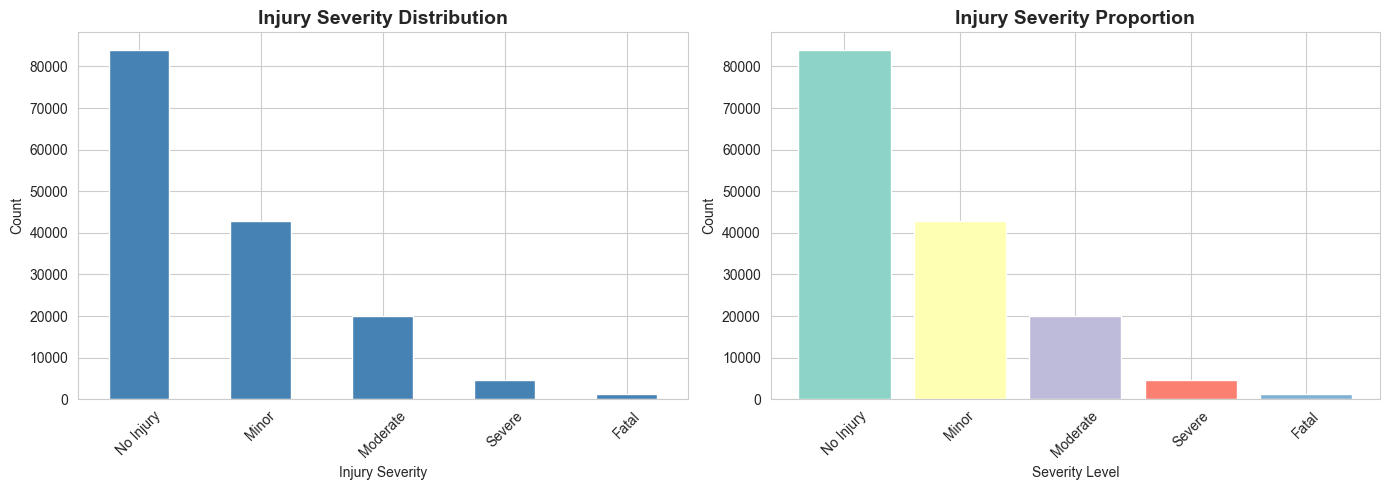

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

severity_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Injury Severity Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Injury Severity')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels([severity_labels[i] for i in severity_counts.index], rotation=45)

colors = plt.cm.Set3(range(len(severity_counts)))
axes[1].bar(range(len(severity_counts)), severity_counts.values, color=colors)
axes[1].set_title('Injury Severity Proportion', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Severity Level')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(len(severity_counts)))
axes[1].set_xticklabels([severity_labels[i] for i in severity_counts.index], rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Temporal Analysis

In [38]:
print("=" * 80)
print("TEMPORAL PATTERNS")
print("=" * 80)
print()

print(f"Date range: {df['CrashDateTime'].min()} to {df['CrashDateTime'].max()}")
print(f"Total years: {df['crash_year'].nunique()}")
print(f"Years covered: {sorted(df['crash_year'].unique())}")

TEMPORAL PATTERNS

Date range: 2011-01-01 00:09:00 to 2024-11-24 22:34:00
Total years: 14
Years covered: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


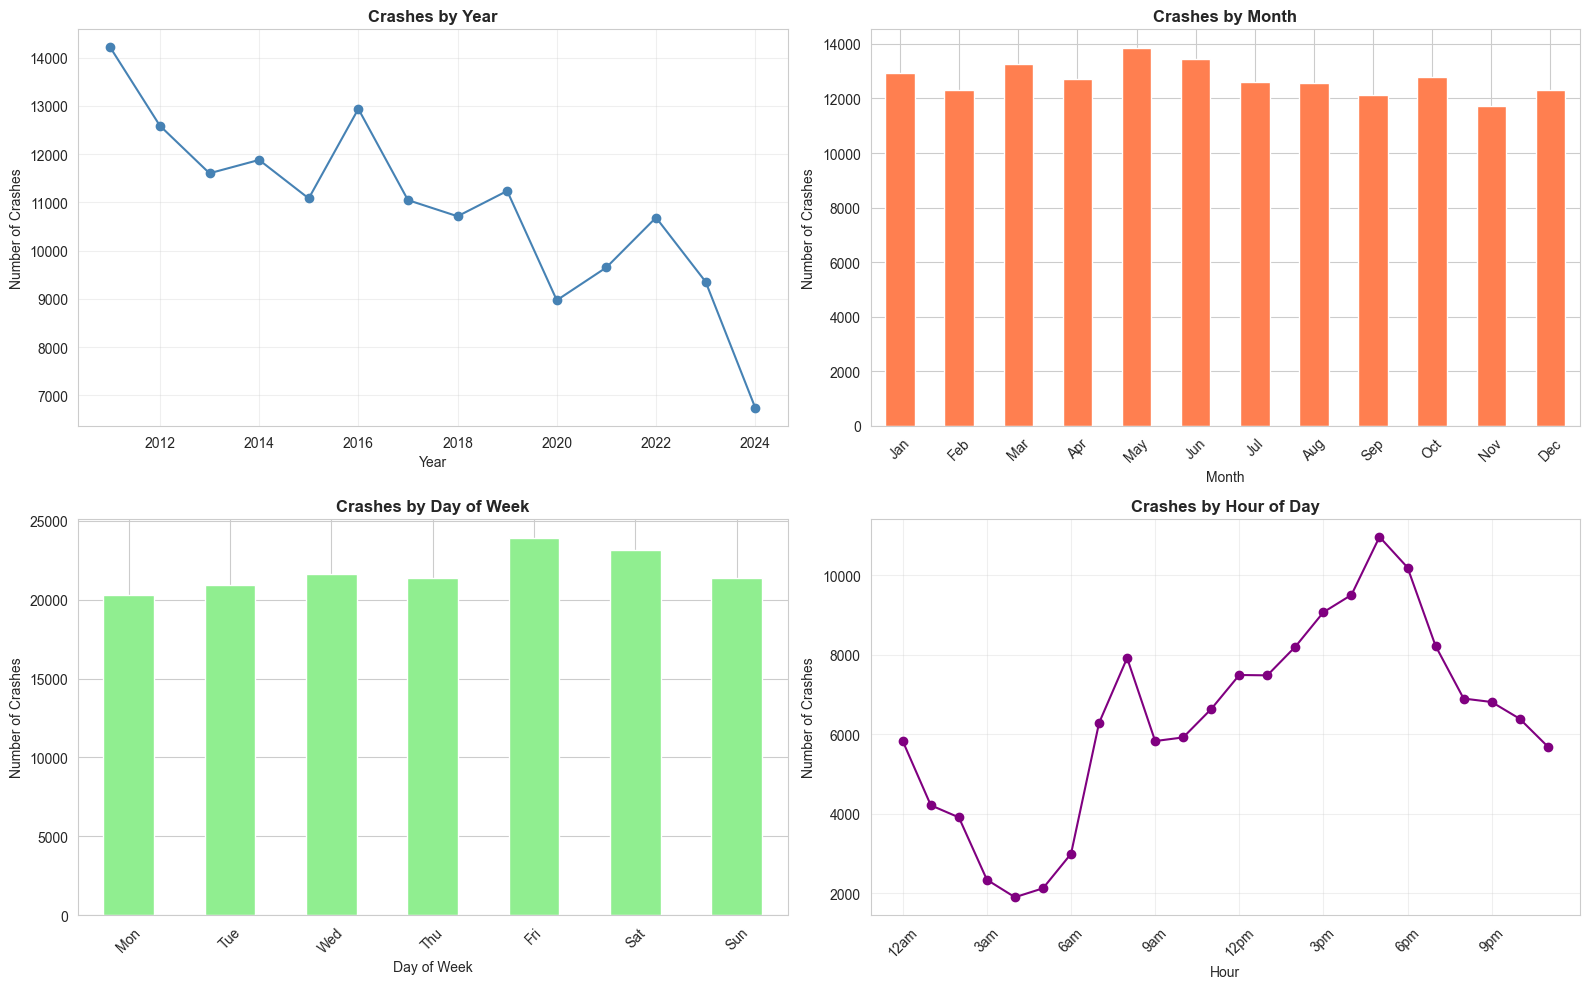

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

yearly = df.groupby('crash_year').size()
yearly.plot(kind='line', ax=axes[0, 0], marker='o', color='steelblue')
axes[0, 0].set_title('Crashes by Year', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Number of Crashes')
axes[0, 0].grid(True, alpha=0.3)

monthly = df.groupby('crash_month').size()
monthly.plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Crashes by Month', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Number of Crashes')
axes[0, 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                             'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)

dow = df.groupby('crash_dayofweek').size()
dow.plot(kind='bar', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Crashes by Day of Week', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Number of Crashes')
axes[1, 0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=45)

hourly = df.groupby('crash_hour').size()
hourly.plot(kind='line', ax=axes[1, 1], marker='o', color='purple')
axes[1, 1].set_title('Crashes by Hour of Day', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Number of Crashes')
hour_labels = ['12am', '1am', '2am', '3am', '4am', '5am', '6am', '7am', '8am', '9am', '10am', '11am',
               '12pm', '1pm', '2pm', '3pm', '4pm', '5pm', '6pm', '7pm', '8pm', '9pm', '10pm', '11pm']
axes[1, 1].set_xticks(range(0, 24, 3))
axes[1, 1].set_xticklabels([hour_labels[i] for i in range(0, 24, 3)], rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'temporal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Severity by Time Patterns

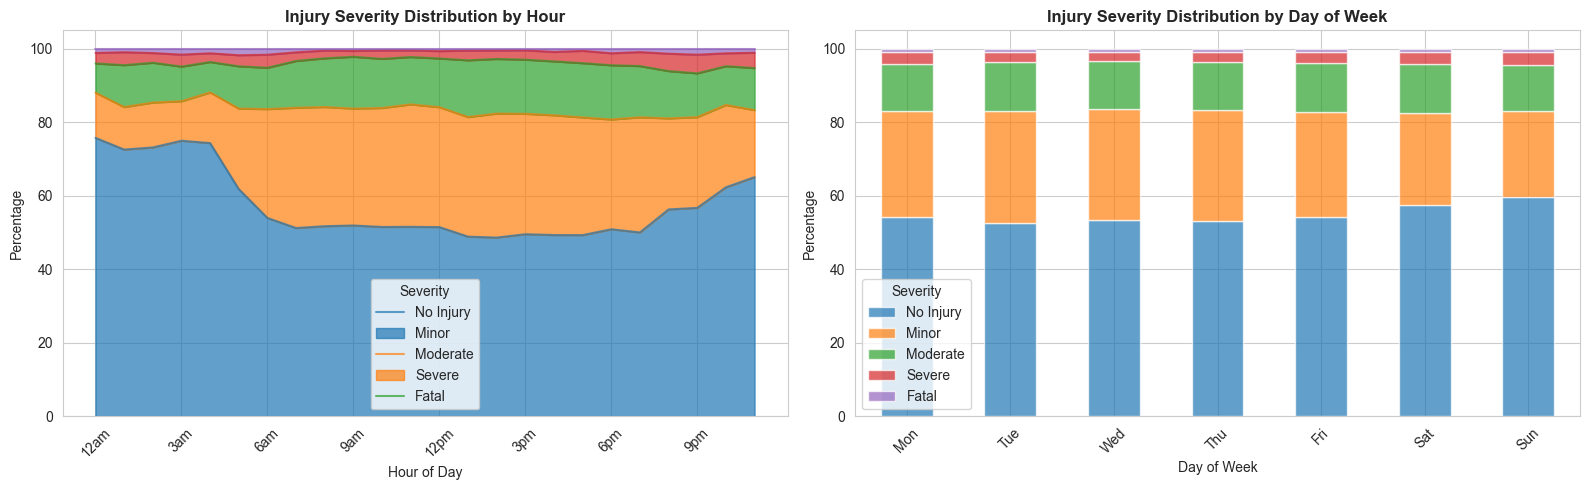

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

severity_by_hour = pd.crosstab(df['crash_hour'], df['injury_severity'], normalize='index') * 100
severity_by_hour.plot(kind='area', stacked=True, ax=axes[0], alpha=0.7)
axes[0].set_title('Injury Severity Distribution by Hour', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Percentage')
hour_labels = ['12am', '1am', '2am', '3am', '4am', '5am', '6am', '7am', '8am', '9am', '10am', '11am',
               '12pm', '1pm', '2pm', '3pm', '4pm', '5pm', '6pm', '7pm', '8pm', '9pm', '10pm', '11pm']
axes[0].set_xticks(range(0, 24, 3))
axes[0].set_xticklabels([hour_labels[i] for i in range(0, 24, 3)], rotation=45)
axes[0].legend(title='Severity', labels=[severity_labels[i] for i in range(5)])

severity_by_dow = pd.crosstab(df['crash_dayofweek'], df['injury_severity'], normalize='index') * 100
severity_by_dow.plot(kind='bar', stacked=True, ax=axes[1], alpha=0.7)
axes[1].set_title('Injury Severity Distribution by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Percentage')
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=45)
axes[1].legend(title='Severity', labels=[severity_labels[i] for i in range(5)])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'severity_temporal.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Environmental Conditions

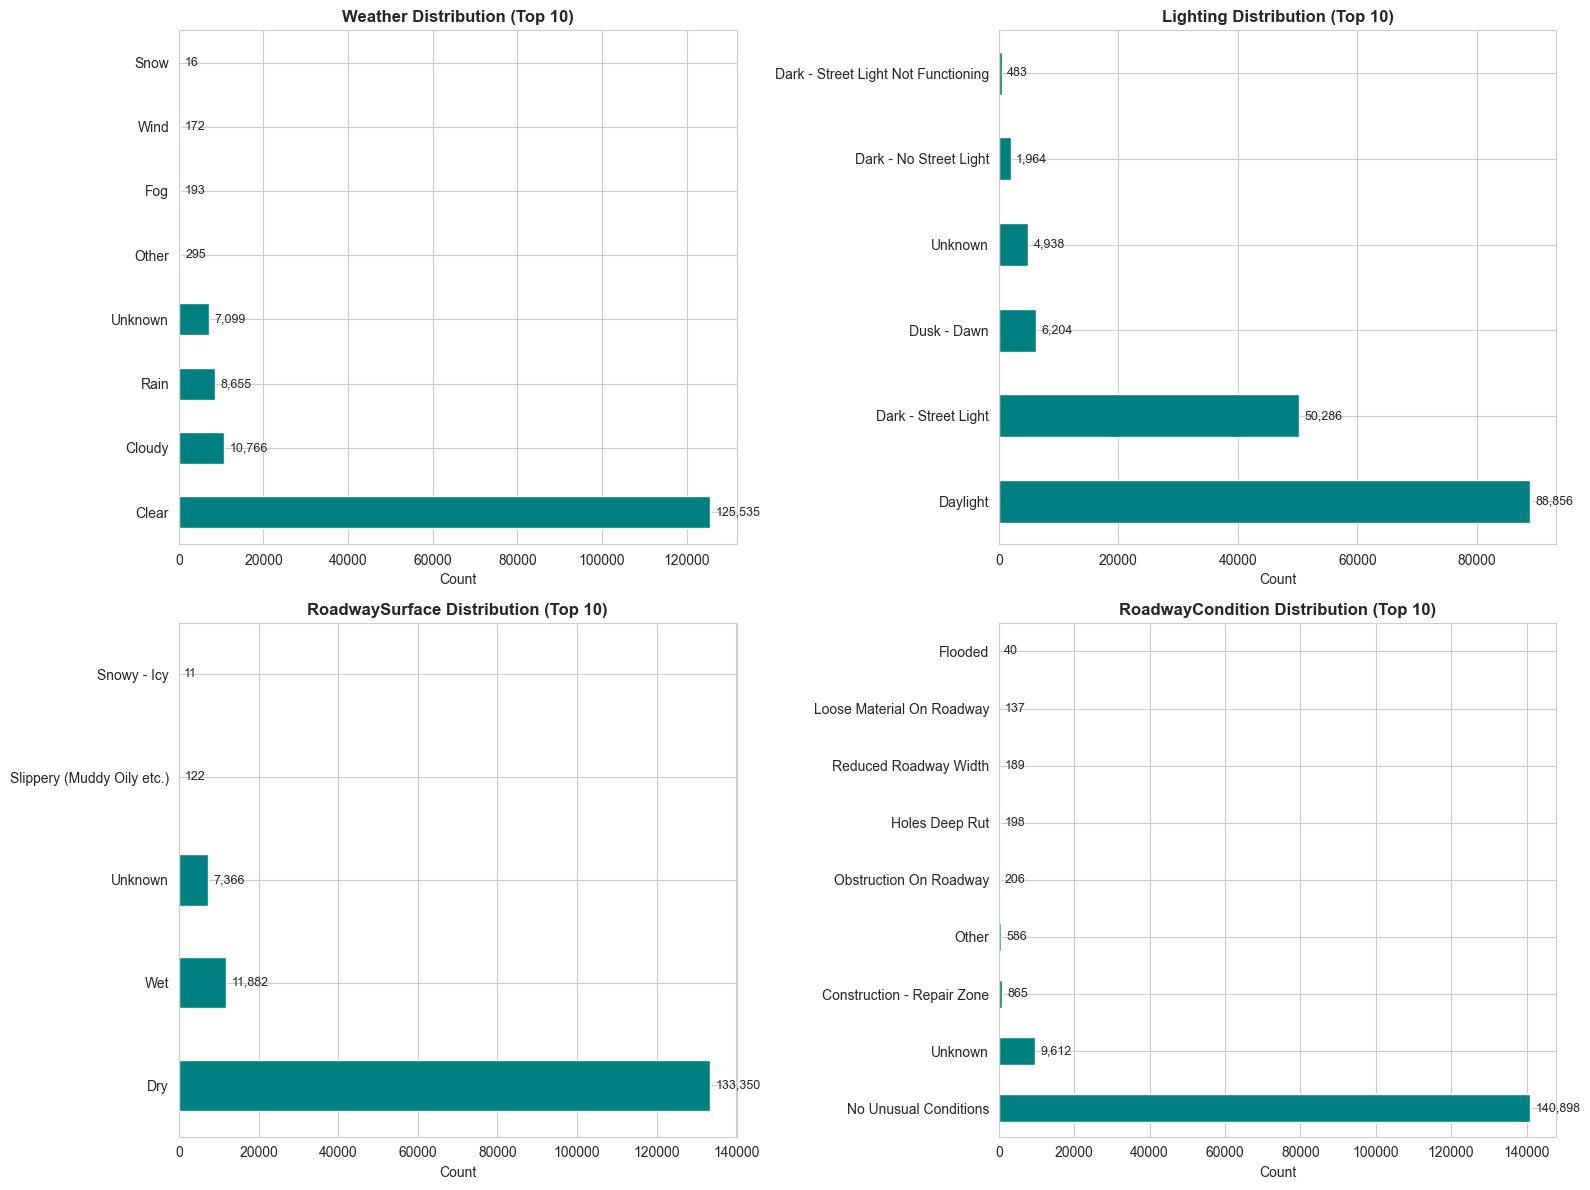

In [41]:
environmental_features = ['Weather', 'Lighting', 'RoadwaySurface', 'RoadwayCondition']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(environmental_features):
    if feature in df.columns:
        top_values = df[feature].value_counts().head(10)
        bars = top_values.plot(kind='barh', ax=axes[idx], color='teal')
        axes[idx].set_title(f'{feature} Distribution (Top 10)', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Count')
        axes[idx].set_ylabel('')
        
        for i, (label, value) in enumerate(top_values.items()):
            axes[idx].text(value + max(top_values) * 0.01, i, f'{int(value):,}', 
                          va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'environmental_conditions.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Collision Characteristics

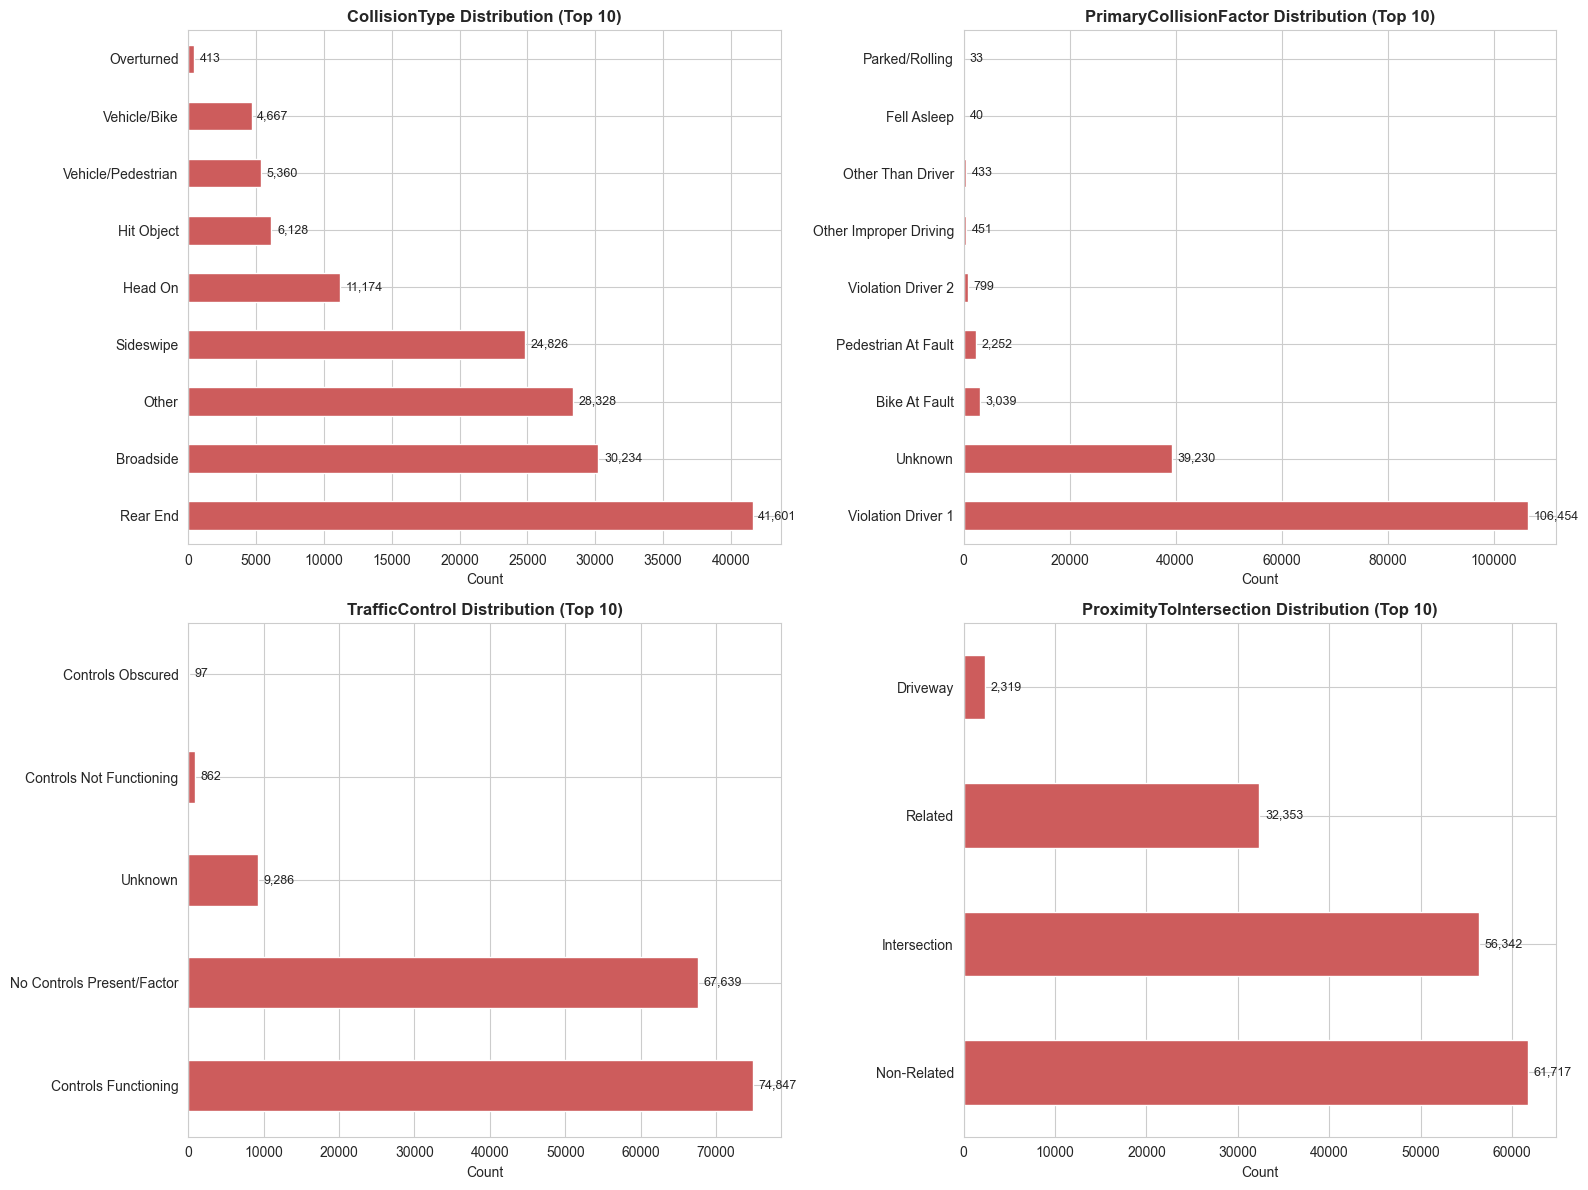

In [42]:
collision_features = ['CollisionType', 'PrimaryCollisionFactor', 'TrafficControl', 'ProximityToIntersection']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(collision_features):
    if feature in df.columns:
        top_values = df[feature].value_counts().head(10)
        bars = top_values.plot(kind='barh', ax=axes[idx], color='indianred')
        axes[idx].set_title(f'{feature} Distribution (Top 10)', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Count')
        axes[idx].set_ylabel('')
        
        for i, (label, value) in enumerate(top_values.items()):
            axes[idx].text(value + max(top_values) * 0.01, i, f'{int(value):,}', 
                          va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'collision_characteristics.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Vehicle and Driver Characteristics

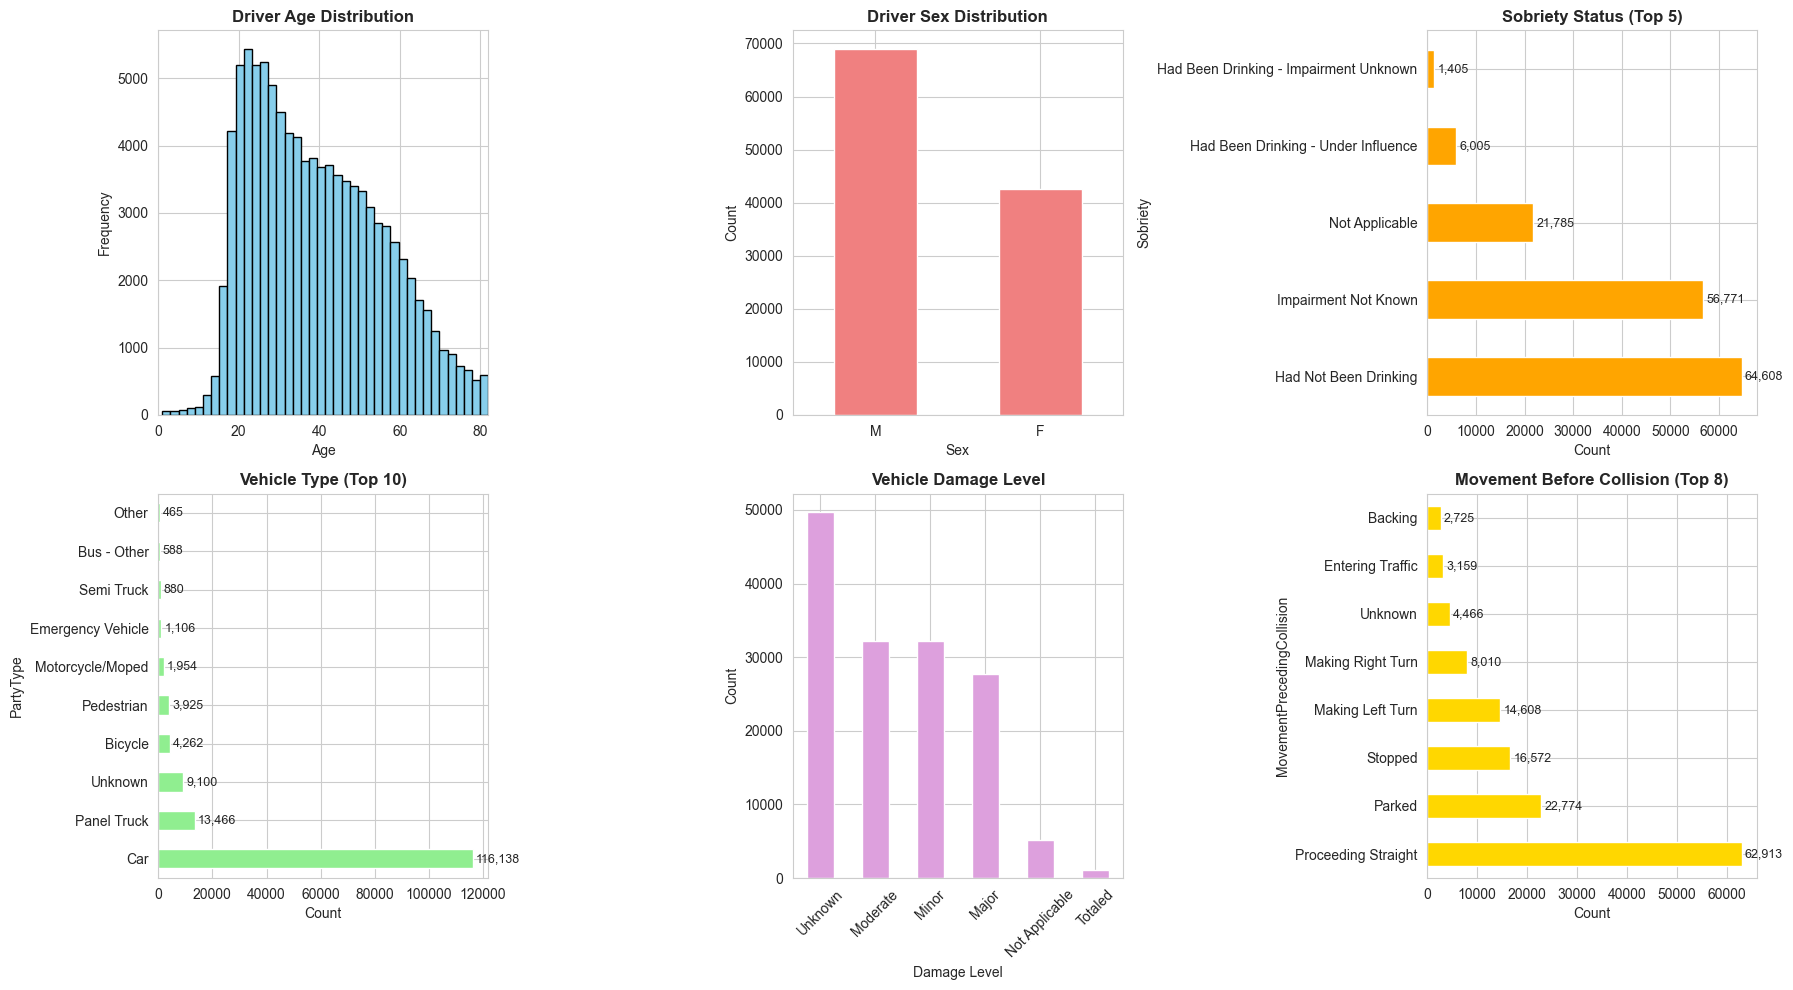

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

if 'Age' in df.columns:
    age_data = df[df['Age'] > 0]['Age']
    max_age = age_data.quantile(0.99)
    age_data[age_data <= max_age].hist(bins=40, ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_title('Driver Age Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Age')
    axes[0].set_ylabel('Frequency')
    axes[0].set_xlim(0, max_age)

if 'Sex' in df.columns:
    df['Sex'].value_counts().plot(kind='bar', ax=axes[1], color='lightcoral')
    axes[1].set_title('Driver Sex Distribution', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Sex')
    axes[1].set_ylabel('Count')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

if 'Sobriety' in df.columns:
    sobriety_counts = df['Sobriety'].value_counts().head(5)
    sobriety_counts.plot(kind='barh', ax=axes[2], color='orange')
    axes[2].set_title('Sobriety Status (Top 5)', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Count')
    for i, (label, value) in enumerate(sobriety_counts.items()):
        axes[2].text(value + max(sobriety_counts) * 0.01, i, f'{int(value):,}', 
                    va='center', fontsize=9)

if 'PartyType' in df.columns:
    party_counts = df['PartyType'].value_counts().head(10)
    party_counts.plot(kind='barh', ax=axes[3], color='lightgreen')
    axes[3].set_title('Vehicle Type (Top 10)', fontsize=12, fontweight='bold')
    axes[3].set_xlabel('Count')
    for i, (label, value) in enumerate(party_counts.items()):
        axes[3].text(value + max(party_counts) * 0.01, i, f'{int(value):,}', 
                    va='center', fontsize=9)

if 'VehicleDamage' in df.columns:
    df['VehicleDamage'].value_counts().plot(kind='bar', ax=axes[4], color='plum')
    axes[4].set_title('Vehicle Damage Level', fontsize=12, fontweight='bold')
    axes[4].set_xlabel('Damage Level')
    axes[4].set_ylabel('Count')
    axes[4].set_xticklabels(axes[4].get_xticklabels(), rotation=45)

if 'MovementPrecedingCollision' in df.columns:
    movement_counts = df['MovementPrecedingCollision'].value_counts().head(8)
    movement_counts.plot(kind='barh', ax=axes[5], color='gold')
    axes[5].set_title('Movement Before Collision (Top 8)', fontsize=12, fontweight='bold')
    axes[5].set_xlabel('Count')
    for i, (label, value) in enumerate(movement_counts.items()):
        axes[5].text(value + max(movement_counts) * 0.01, i, f'{int(value):,}', 
                    va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'vehicle_driver_characteristics.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Severity Analysis by Key Features


SEVERITY BY WEATHER


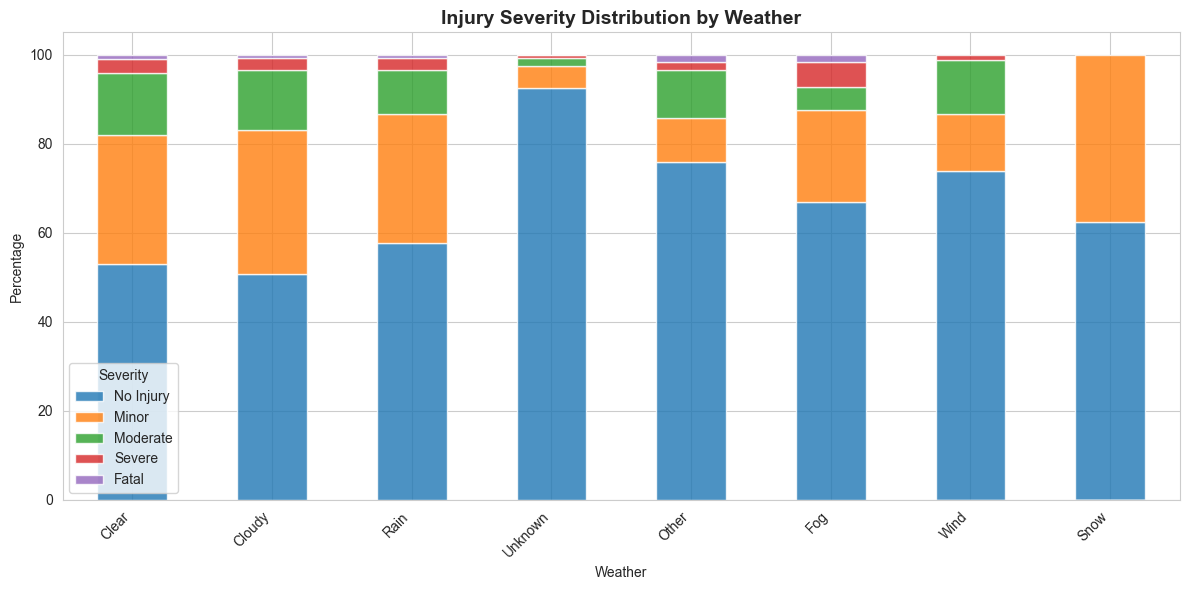


Severity percentages:
injury_severity      0      1      2     3     4
Weather                                         
Clear            52.97  28.99  13.99  3.14  0.91
Cloudy           50.70  32.44  13.32  2.70  0.85
Rain             57.64  29.09   9.72  2.75  0.80
Unknown          92.59   4.94   1.80  0.49  0.17
Other            75.93   9.83  10.85  1.69  1.69
Fog              66.84  20.73   5.18  5.70  1.55
Wind             73.84  12.79  12.21  1.16  0.00
Snow             62.50  37.50   0.00  0.00  0.00

SEVERITY BY LIGHTING


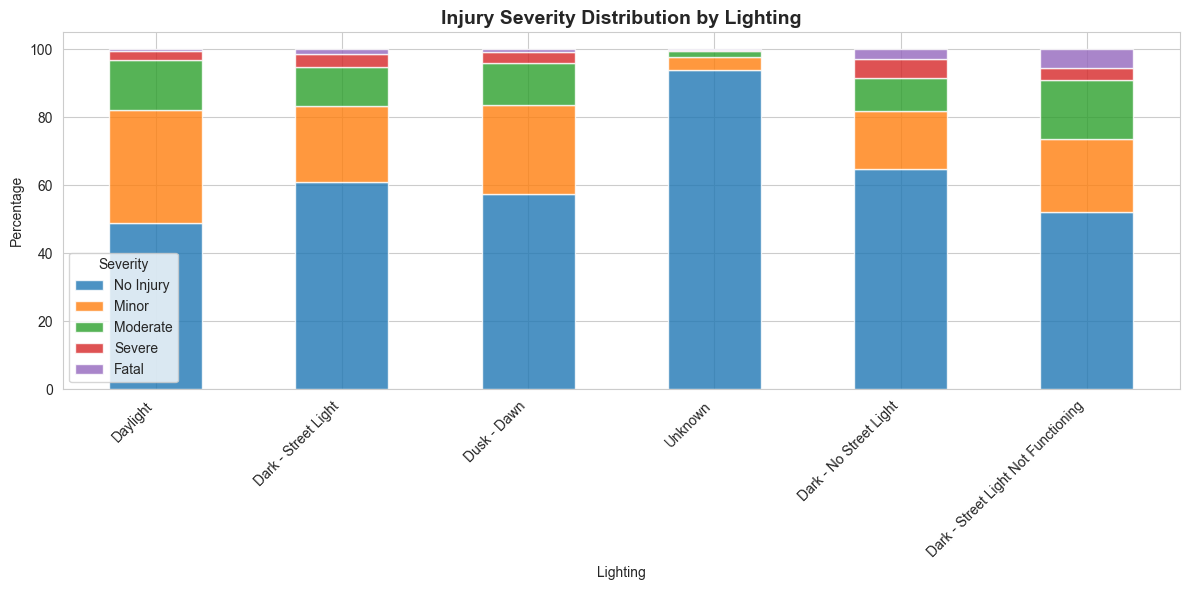


Severity percentages:
injury_severity                          0      1      2     3     4
Lighting                                                            
Daylight                             49.08  33.10  14.80  2.44  0.58
Dark - Street Light                  60.98  22.24  11.46  3.99  1.33
Dusk - Dawn                          57.56  26.16  12.22  3.27  0.79
Unknown                              93.94   3.81   1.80  0.38  0.06
Dark - No Street Light               64.92  16.96   9.83  5.55  2.75
Dark - Street Light Not Functioning  52.17  21.53  17.18  3.73  5.38

SEVERITY BY COLLISIONTYPE


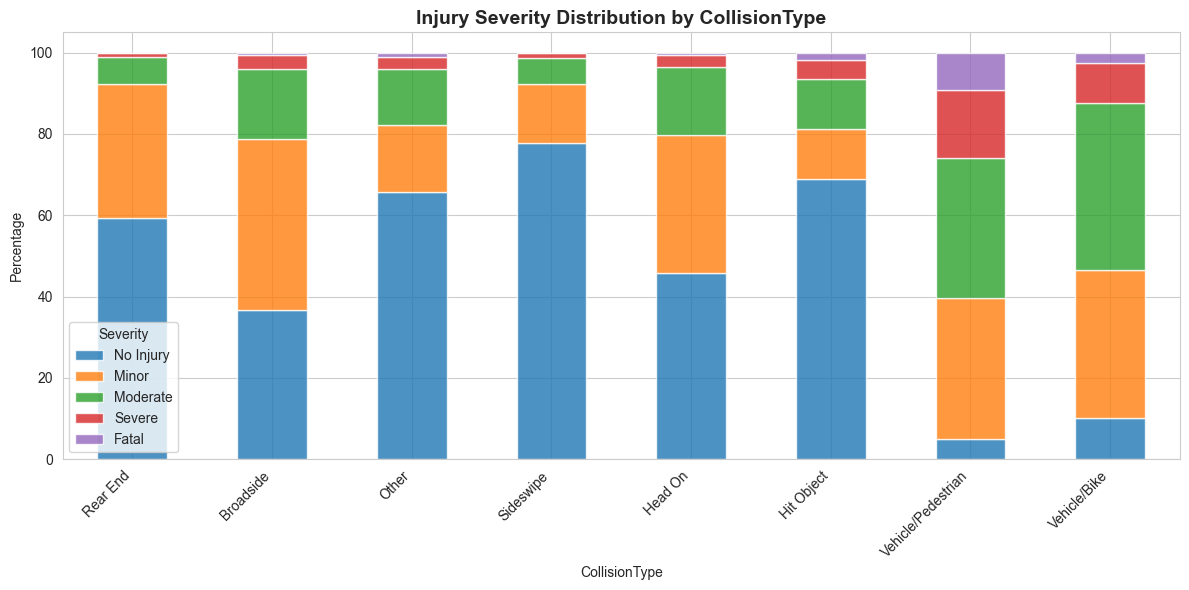


Severity percentages:
injury_severity         0      1      2      3     4
CollisionType                                       
Rear End            59.45  32.88   6.61   0.92  0.14
Broadside           36.78  42.07  17.20   3.36  0.59
Other               65.64  16.47  13.98   2.95  0.96
Sideswipe           77.80  14.47   6.48   1.12  0.14
Head On             45.79  33.84  16.76   3.15  0.46
Hit Object          68.88  12.45  12.19   4.77  1.71
Vehicle/Pedestrian   5.06  34.63  34.51  16.57  9.24
Vehicle/Bike        10.11  36.34  41.25   9.75  2.55

SEVERITY BY SOBRIETY


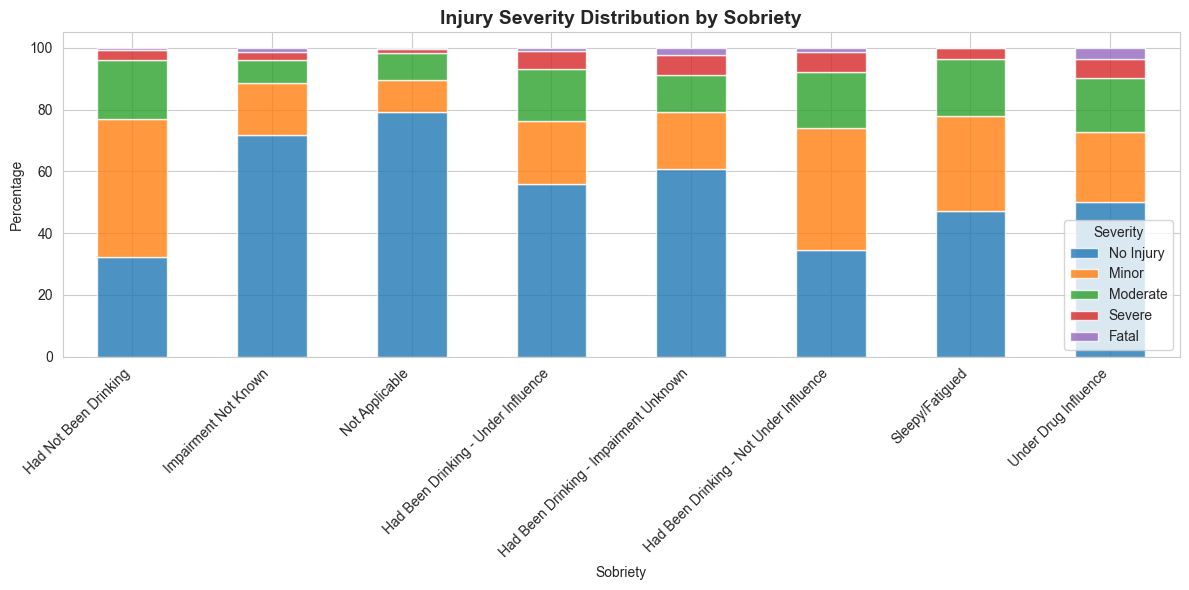


Severity percentages:
injury_severity                              0      1      2     3     4
Sobriety                                                                
Had Not Been Drinking                    32.37  44.65  18.88  3.52  0.59
Impairment Not Known                     71.76  16.79   7.65  2.49  1.31
Not Applicable                           79.27  10.21   8.88  1.33  0.31
Had Been Drinking - Under Influence      55.92  20.48  16.67  5.88  1.05
Had Been Drinking - Impairment Unknown   60.93  18.22  12.03  6.41  2.42
Had Been Drinking - Not Under Influence  34.42  39.54  18.36  6.27  1.41
Sleepy/Fatigued                          47.31  30.61  18.37  3.53  0.19
Under Drug Influence                     50.00  22.87  17.44  6.20  3.49


In [44]:
key_features = ['Weather', 'Lighting', 'CollisionType', 'Sobriety']

for feature in key_features:
    if feature in df.columns:
        print(f"\n{'=' * 80}")
        print(f"SEVERITY BY {feature.upper()}")
        print('=' * 80)
        
        severity_by_feature = pd.crosstab(df[feature], df['injury_severity'], normalize='index') * 100
        top_categories = df[feature].value_counts().head(8).index
        severity_subset = severity_by_feature.loc[top_categories]
        
        fig, ax = plt.subplots(figsize=(12, 6))
        severity_subset.plot(kind='bar', stacked=True, ax=ax, alpha=0.8)
        ax.set_title(f'Injury Severity Distribution by {feature}', fontsize=14, fontweight='bold')
        ax.set_xlabel(feature)
        ax.set_ylabel('Percentage')
        
        if feature == 'Weather':
            ax.legend(title='Severity', labels=[severity_labels[i] for i in range(5)], loc='lower left')
        else:
            ax.legend(title='Severity', labels=[severity_labels[i] for i in range(5)])
        
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f'severity_by_{feature.lower()}.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\nSeverity percentages:")
        print(severity_subset.round(2))

## 9. Spatial Analysis

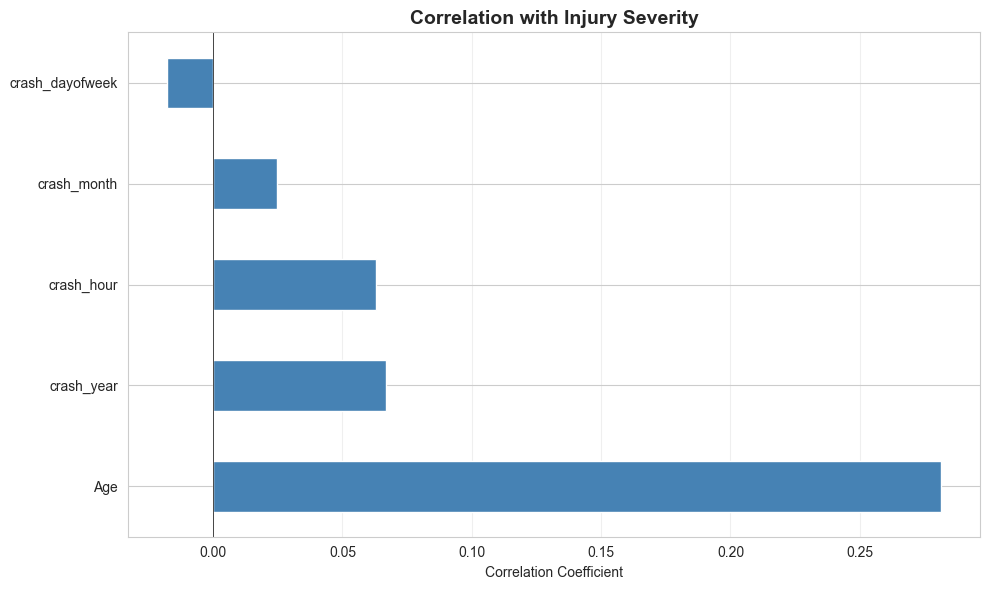


Correlation coefficients explained:
These numbers show how strongly each feature relates to injury severity.
Range: -1 to +1
  • Positive values: Higher feature value → More severe injuries
  • Negative values: Higher feature value → Less severe injuries
  • Values near 0: Little to no relationship

Interpretation:
  • Age (0.281): Older drivers tend to have more severe injuries
  • crash_hour (0.063): Late night/early morning slightly more severe
  • crash_dayofweek (-0.018): Day of week has minimal impact
  • crash_month (0.025): Month has minimal impact
  • crash_year (0.067): Year has minimal impact

Key takeaway: Age is the strongest predictor among these features.
Environmental/collision factors (weather, collision type) likely matter more
than temporal patterns for predicting severity.


In [ ]:
print("=" * 80)
print("FEATURE IMPORTANCE: CATEGORICAL ASSOCIATIONS WITH SEVERITY")
print("=" * 80)
print("\nAnalyzing which categorical features have the strongest relationship")
print("with injury severity using Cramér's V (0 = no association, 1 = perfect association)")
print()

from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calculate Cramér's V statistic for categorical-categorical association."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

categorical_features = [
    'CollisionType',
    'Weather', 
    'Lighting',
    'RoadwaySurface',
    'RoadwayCondition',
    'PrimaryCollisionFactor',
    'TrafficControl',
    'Sobriety',
    'VehicleDamage',
    'PartyType',
    'MovementPrecedingCollision',
    'ProximityToIntersection',
    'VehicleInvolvedWith'
]

feature_associations = {}
for feature in categorical_features:
    if feature in df.columns:
        valid_data = df[[feature, 'injury_severity']].dropna()
        if len(valid_data) > 0:
            v_stat = cramers_v(valid_data[feature], valid_data['injury_severity'])
            feature_associations[feature] = v_stat

associations_df = pd.DataFrame.from_dict(feature_associations, orient='index', columns=['Cramers_V'])
associations_df = associations_df.sort_values('Cramers_V', ascending=False)

print(associations_df)
print()
print("Interpretation:")
print("  • 0.00-0.10: Negligible association")
print("  • 0.10-0.20: Weak association")
print("  • 0.20-0.30: Moderate association")
print("  • 0.30+: Strong association")
print()

fig, ax = plt.subplots(figsize=(10, 8))
associations_df.plot(kind='barh', ax=ax, color='steelblue', legend=False)
ax.set_title('Feature Association with Injury Severity (Cramér\'s V)', fontsize=14, fontweight='bold')
ax.set_xlabel('Cramér\'s V Statistic')
ax.set_ylabel('Feature')
ax.axvline(x=0.1, color='orange', linestyle='--', alpha=0.5, label='Weak threshold')
ax.axvline(x=0.2, color='red', linestyle='--', alpha=0.5, label='Moderate threshold')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_associations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nKey findings:")
top_3 = associations_df.head(3)
for feature, row in top_3.iterrows():
    print(f"  • {feature}: {row['Cramers_V']:.3f}")
print("\nThese features should be prioritized in modeling.")
print("=" * 80)

## 10. Correlation Analysis

Looking at which numeric features relate to injury severity.

Correlation with injury_severity:
Age                0.281495
crash_year         0.066827
crash_hour         0.062932
crash_month        0.024687
crash_dayofweek   -0.017926
Name: injury_severity, dtype: float64

Interpretation:
- Age has strongest correlation (0.28) - older drivers = more severe injuries
- crash_hour (0.06) - late night/early morning slightly more severe
- Other temporal features show weak correlation
- This suggests environmental/collision factors matter more than time


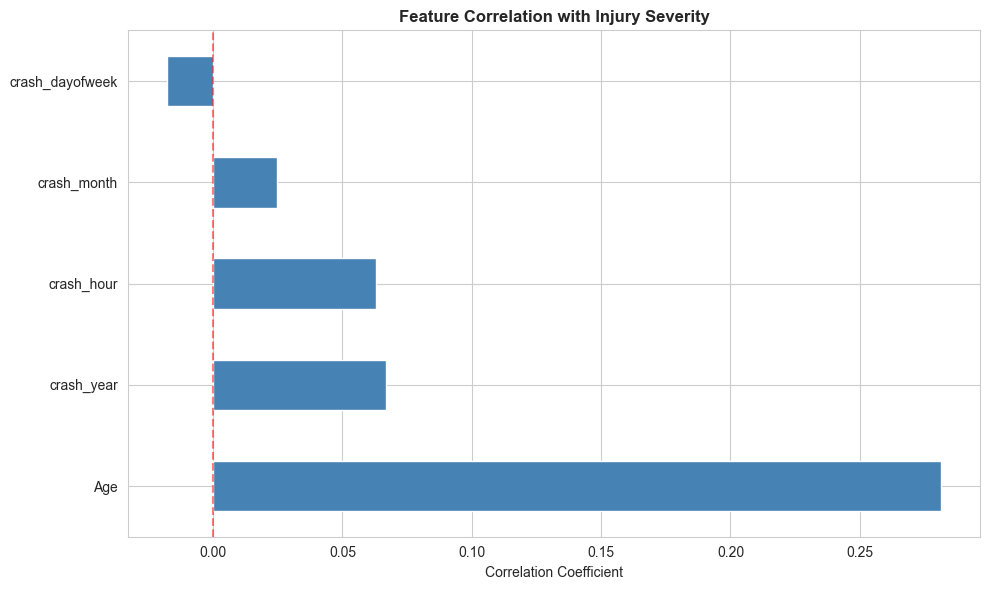

In [46]:
key_numeric = ['crash_year', 'crash_month', 'crash_hour', 'crash_dayofweek', 'Age']
key_numeric = [col for col in key_numeric if col in df.columns]

if key_numeric:
    corr_data = df[key_numeric + ['injury_severity']].corr()
    severity_corr = corr_data['injury_severity'].drop('injury_severity').sort_values(ascending=False)
    
    print("Correlation with injury_severity:")
    print(severity_corr)
    print("\nInterpretation:")
    print("- Age has strongest correlation (0.28) - older drivers = more severe injuries")
    print("- crash_hour (0.06) - late night/early morning slightly more severe")
    print("- Other temporal features show weak correlation")
    print("- This suggests environmental/collision factors matter more than time")
    
    plt.figure(figsize=(10, 6))
    severity_corr.plot(kind='barh', color='steelblue')
    plt.title('Feature Correlation with Injury Severity', fontsize=12, fontweight='bold')
    plt.xlabel('Correlation Coefficient')
    plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'correlation_severity.png', dpi=300, bbox_inches='tight')
    plt.show()

## 11. Missing Data Analysis


Features with missing values:
                          Missing_Count  Missing_Percentage
Race                             140203               91.80
Comment                          140077               91.71
VehicleMakeModelType             135502               88.72
TrailerAttached                  133629               87.49
PartySubType                     133629               87.49
HitAndRunFlag                    125944               82.46
SpeedingFlag                     125944               82.46
MinorInjuries_vehicle            123893               81.12
ModerateInjuries_vehicle         123884               81.11
SevereInjuries_vehicle           123884               81.11
FatalInjuries_vehicle            123880               81.11
PossibleTransientFlag            123860               81.10
InattentionCodes                 123860               81.10
SafetyEquipment                  123860               81.10
SafetyEquipmentCategory          123860               81.10
Speed    

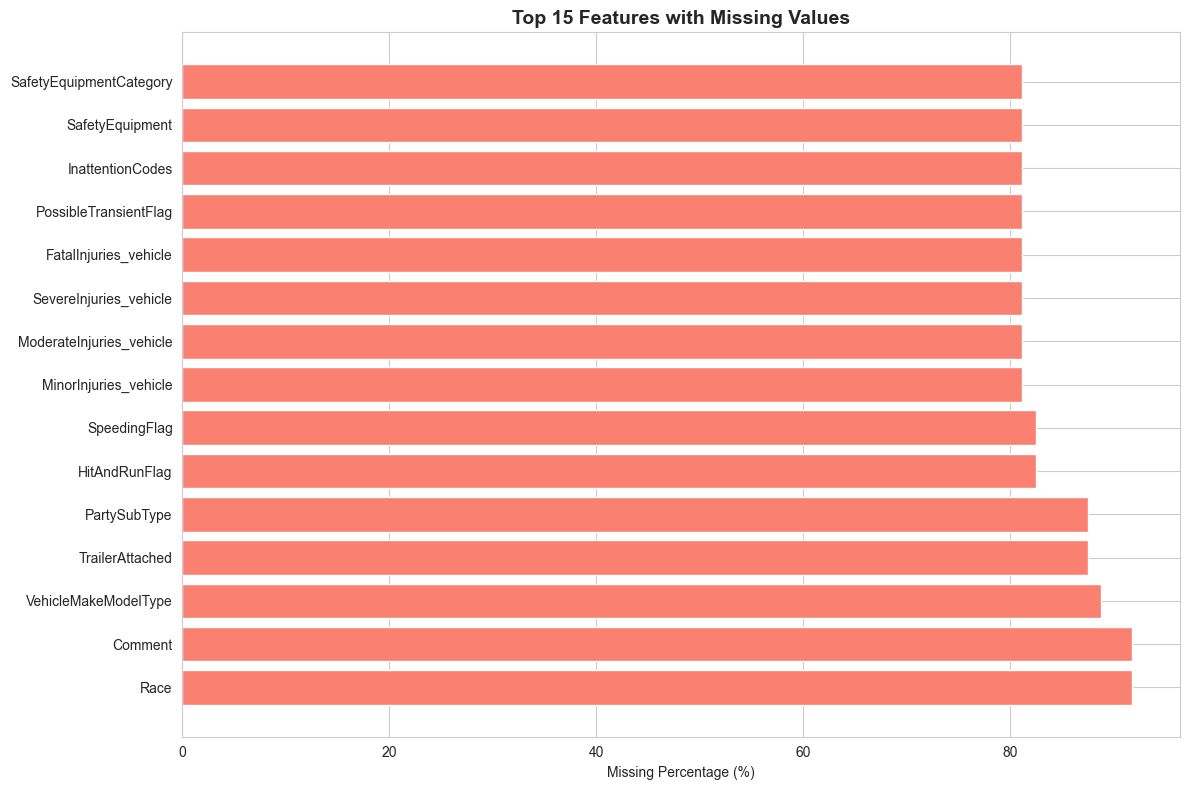

In [47]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_pct
}).sort_values('Missing_Count', ascending=False)

missing_df = missing_df[missing_df['Missing_Count'] > 0]

if len(missing_df) > 0:
    print("\nFeatures with missing values:")
    print(missing_df.head(20))
    
    plt.figure(figsize=(12, 8))
    top_missing = missing_df.head(15)
    plt.barh(range(len(top_missing)), top_missing['Missing_Percentage'], color='salmon')
    plt.yticks(range(len(top_missing)), top_missing.index)
    plt.xlabel('Missing Percentage (%)')
    plt.title('Top 15 Features with Missing Values', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'missing_values.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\nNo missing values found!")

## 12. Key Takeaways

In [48]:
print("=" * 80)
print("KEY INSIGHTS FROM EDA")
print("=" * 80)
print()

print("1. TARGET VARIABLE:")
print(f"   - Highly imbalanced: {severity_counts.max() / severity_counts.min():.1f}:1 ratio")
print(f"   - Majority class (No Injury): {severity_pct[0]:.1f}%")
print(f"   - Fatal crashes: {severity_pct[4]:.2f}%")
print()

print("2. TEMPORAL PATTERNS:")
peak_hour = df['crash_hour'].value_counts().idxmax()
peak_dow = df['crash_dayofweek'].value_counts().idxmax()
dow_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
print(f"   - Peak crash hour: {peak_hour}:00")
print(f"   - Most crashes on: {dow_names[peak_dow]}")
print()

print("3. ENVIRONMENTAL CONDITIONS:")
if 'Weather' in df.columns:
    top_weather = df['Weather'].value_counts().index[0]
    print(f"   - Most common weather: {top_weather}")
if 'Lighting' in df.columns:
    top_lighting = df['Lighting'].value_counts().index[0]
    print(f"   - Most common lighting: {top_lighting}")
print()

print("4. DATA QUALITY:")
print(f"   - Total records: {len(df):,}")
print(f"   - Features with >50% missing: {len(missing_df[missing_df['Missing_Percentage'] > 50])}")
print(f"   - Records with coordinates: {len(valid_coords):,} ({len(valid_coords)/len(df)*100:.1f}%)")
print()

print("5. NEXT STEPS:")
print("   - Feature engineering for temporal patterns")
print("   - Handle class imbalance (SMOTE, class weights)")
print("   - Encode categorical variables")
print("   - Consider feature selection based on correlations")
print("   - Address missing values strategically")

KEY INSIGHTS FROM EDA

1. TARGET VARIABLE:
   - Highly imbalanced: 63.8:1 ratio
   - Majority class (No Injury): 55.0%
   - Fatal crashes: 0.86%

2. TEMPORAL PATTERNS:
   - Peak crash hour: 17:00
   - Most crashes on: Friday

3. ENVIRONMENTAL CONDITIONS:
   - Most common weather: Clear
   - Most common lighting: Daylight

4. DATA QUALITY:
   - Total records: 152,731
   - Features with >50% missing: 16
   - Records with coordinates: 152,724 (100.0%)

5. NEXT STEPS:
   - Feature engineering for temporal patterns
   - Handle class imbalance (SMOTE, class weights)
   - Encode categorical variables
   - Consider feature selection based on correlations
   - Address missing values strategically
